Used PowerTransformer (Yeo-Johnson)


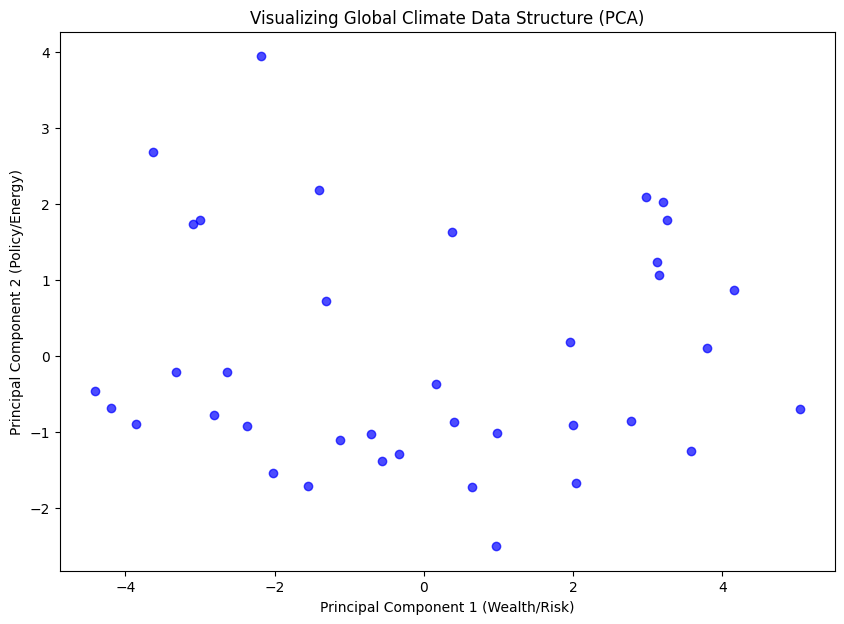

In [1]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import sys
import os

sys.path.append(os.path.abspath(os.path.join('..', ''))) 

from src.preprocessing import preprocess_dataset
from src.preprocessing import preprocess_dataset

# Get the  unscaled data
# Can specify which method to use in the preprocess_dataset function: 'standard' or 'power'
X_scaled = preprocess_dataset('../data/processed/cleaned_feature_matrix.csv',
                             '../data/processed/cleaned_and_scaled.csv',
                             method='power')

# Reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, c='blue')
plt.title("Visualizing Global Climate Data Structure (PCA)")
plt.xlabel("Principal Component 1 (Wealth/Risk)")
plt.ylabel("Principal Component 2 (Policy/Energy)")
plt.show()

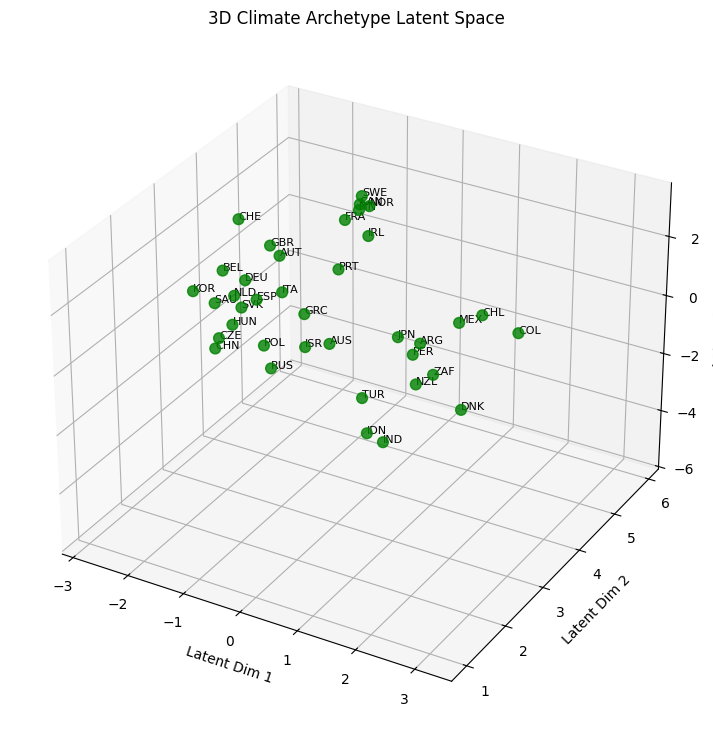

In [7]:
from sklearn.neural_network import MLPRegressor
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 

# Get the list of countries from the original dataset for labeling
countries = pd.read_csv('../data/processed/cleaned_feature_matrix.csv')['country_code'].values

# Architecture
ae_3d = MLPRegressor(
    hidden_layer_sizes=(3,), 
    activation='relu', 
    solver='lbfgs',      
    max_iter=2000,       # Increased for the extra complexity
    random_state=42
)

# Train
ae_3d.fit(X_scaled, X_scaled)

# Extract the latent space representation
weights = ae_3d.coefs_[0]
biases = ae_3d.intercepts_[0]
X_ae_3d = np.dot(X_scaled, weights) + biases

# 3D Visualization
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(X_ae_3d[:, 0], X_ae_3d[:, 1], X_ae_3d[:, 2], 
                     alpha=0.8, c='green', s=60)

for i in range(len(countries)):
    ax.text(X_ae_3d[i, 0], X_ae_3d[i, 1], X_ae_3d[i, 2], 
            countries[i], size=8, zorder=1, color='black')

ax.set_title("3D Climate Archetype Latent Space")
ax.set_xlabel("Latent Dim 1")
ax.set_ylabel("Latent Dim 2")
ax.set_zlabel("Latent Dim 3")

plt.show()